# Recurrent Neural Network (RNN)

## Content
* [Sequence Models](#1)
* [Recurrent Neural Network (RNN)](#2)
* [Implementing Recurrent Neural Network with Keras](#3)
    * [Loading and Preprocessing Data](#31)
    * [Create RNN Model](#32)
    * [Predictions and Visualising RNN Model](#33)
* [Long Short Term Memory (LSTMs)](#4)
* [Implementing Long Short Term Memory with Keras](#99)
    * [Loading and Visualizing Data](#41)
    * [Preprocessing Data](#42)
    * [Create LSTM Model](#43)
    * [Predictions and Visualising LSTM Model](#44)
* [Conclusion](#6)

<a id="1"></a>
## Sequence Models
* Sequence models plays an over time. 
* Speech recognition, natural language process (NLP), music generation
* Apples Siri and Google's voice search
* Sentiment classification 


<a id="2"></a>
## Recurrent Neural Network

<a id="41"></a>
### Loading and Visualizing Data

In [1]:
import numpy as np 
import pandas as pd 


import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
    
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation

import os
print(os.listdir("../input"))

['international-airline-passengers.csv']


Using TensorFlow backend.


In [2]:
data = pd.read_csv('../input/international-airline-passengers.csv', skipfooter=5)
data.head()

,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
data.columns = ['Month', 'target']

In [4]:
data.Month = pd.to_datetime(data.Month)
dataset = data.target.values

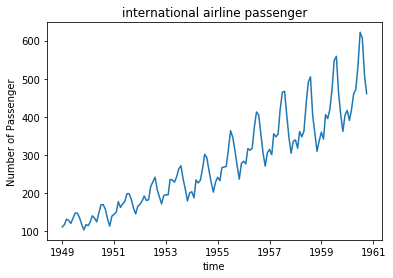

In [5]:
plt.plot(data.Month, data.target)
plt.xlabel("time")
plt.ylabel("Number of Passenger")
plt.title("international airline passenger")
plt.show()

<a id="42"></a>
### Preprocessing Data
* reshape
* change type
* scaling
* train test split
* Create dataset

In [6]:
dataset = dataset.reshape(-1,1)
dataset = dataset.astype("float32")
dataset.shape

(142, 1)

In [7]:
# Feature Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
dataset_scaled = scaler.fit_transform(dataset)

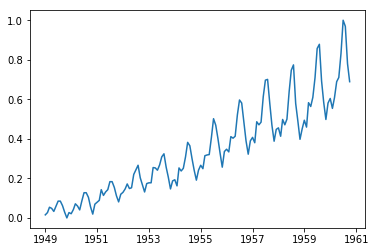

In [8]:
plt.plot(data.Month, dataset_scaled)
plt.show()

In [9]:
train_size = int(len(dataset) * 0.6)
test_size = len(dataset) - train_size
train = dataset_scaled[:train_size, :]
test = dataset_scaled[train_size:, :]
print("train size: {}, test size: {} ".format(len(train), len(test)))

train size: 85, test size: 57 


In [10]:
def prepare(dataset, window=10, gap=2):
    X = []
    Y = []
    for start in range(len(dataset) - window - gap):
        end = start + window
        a = train[start:end, 0]
        X.append(a)
        Y.append(dataset[end + gap, 0])

    return np.array(X), np.array(Y)

In [11]:
window = 10 
gap = 2

In [12]:
X_train, Y_train = prepare(train, window=window, gap=gap)

In [13]:
X_test, Y_test = prepare(test, window=window, gap=gap)

In [14]:
X_train = X_train[:, :, None]
X_test = X_test[:, :, None]

print('shape of X_train: ', X_train.shape)
print('shape of X_test: ', X_test.shape)

shape of X_train:  (73, 10, 1)
shape of X_test:  (45, 10, 1)


<a id="43"></a>
### Create RNN Model

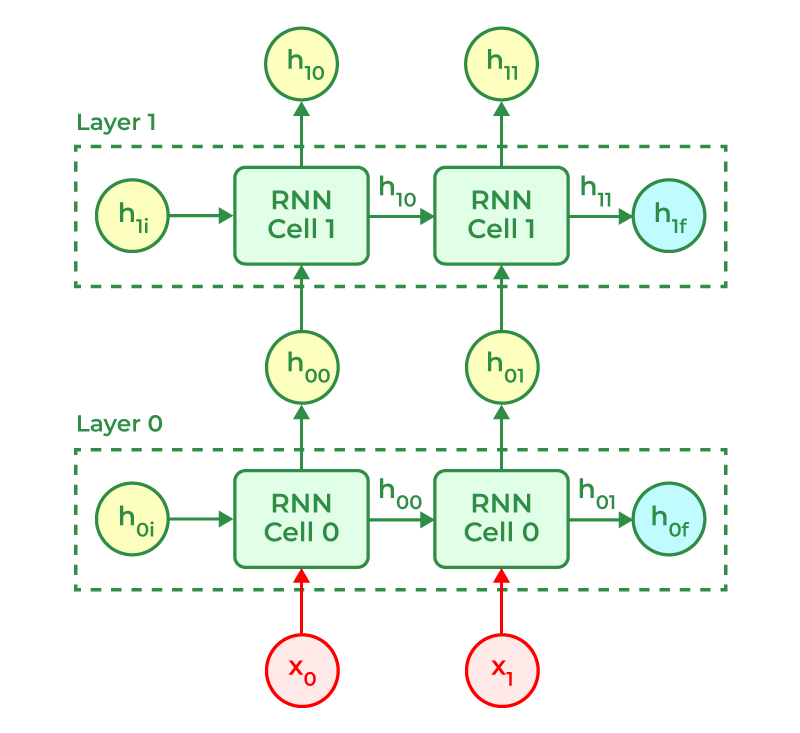

In [15]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout

# Initialising the RNN
regressor = Sequential()

# Adding the first RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 100, activation='relu', return_sequences = True, input_shape = (window, 1)))
regressor.add(Dropout(0.2))

# Adding a second RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 80, activation='relu', return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a third RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 50, activation='relu', return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a fourth RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 30, activation='relu', return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a fifth RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 20))
regressor.add(Dropout(0.2))

# Adding the output layer
regressor.add(Dense(units = 1))

# Compiling the RNN
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

# Fitting the RNN to the Training set
regressor.fit(X_train, Y_train, epochs = 250, batch_size = 50, verbose=-1)

Epoch 1/250
Epoch 2/250
Epoch 3/250
Epoch 4/250
Epoch 5/250
Epoch 6/250
Epoch 7/250
Epoch 8/250
Epoch 9/250
Epoch 10/250
Epoch 11/250
Epoch 12/250
Epoch 13/250
Epoch 14/250
Epoch 15/250
Epoch 16/250
Epoch 17/250
Epoch 18/250
Epoch 19/250
Epoch 20/250
Epoch 21/250
Epoch 22/250
Epoch 23/250
Epoch 24/250
Epoch 25/250
Epoch 26/250
Epoch 27/250
Epoch 28/250
Epoch 29/250
Epoch 30/250
Epoch 31/250
Epoch 32/250
Epoch 33/250
Epoch 34/250
Epoch 35/250
Epoch 36/250
Epoch 37/250
Epoch 38/250
Epoch 39/250
Epoch 40/250
Epoch 41/250
Epoch 42/250
Epoch 43/250
Epoch 44/250
Epoch 45/250
Epoch 46/250
Epoch 47/250
Epoch 48/250
Epoch 49/250
Epoch 50/250
Epoch 51/250
Epoch 52/250
Epoch 53/250
Epoch 54/250
Epoch 55/250
Epoch 56/250
Epoch 57/250
Epoch 58/250
Epoch 59/250
Epoch 60/250
Epoch 61/250
Epoch 62/250
Epoch 63/250
Epoch 64/250
Epoch 65/250
Epoch 66/250
Epoch 67/250
Epoch 68/250
Epoch 69/250
Epoch 70/250
Epoch 71/250
Epoch 72/250
Epoch 73/250
Epoch 74/250
Epoch 75/250
Epoch 76/250
Epoch 77/250
Epoch 78

Predictions and Visualising RNN Model

In [16]:
import math 
from sklearn.metrics import mean_squared_error

y_train = regressor.predict(X_train)
y_test = regressor.predict(X_test)

# invert predictions
y_train = scaler.inverse_transform(y_train)
Y_train = scaler.inverse_transform(Y_train[:, None])
y_test = scaler.inverse_transform(y_test)
Y_test = scaler.inverse_transform(Y_test[:, None])

In [17]:
# calculate root mean squared error
trainScore = mean_squared_error(Y_train[:, 0], y_train[:, 0])
print('Train Score: %.2f MAE' % (trainScore))

testScore = mean_squared_error(Y_test[:, 0], y_test[:, 0])
print('Test Score: %.2f MAE' % (testScore))

Train Score: 481.09 MAE
Test Score: 62351.63 MAE


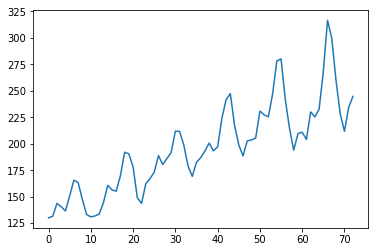

In [18]:
plt.plot(y_train)

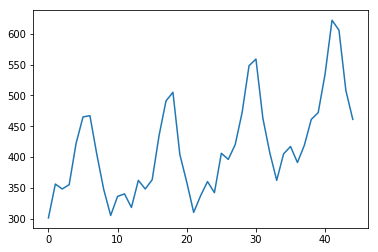

In [19]:
plt.plot(Y_test)

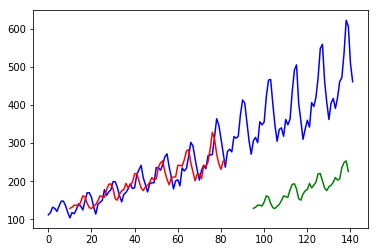

In [20]:
# shifting train
trainPredictPlot = np.empty_like(dataset[:, 0])
trainPredictPlot[:] = np.nan
trainPredictPlot[window: len(y_train[:, 0]) + window] = y_train[:, 0]

# shifting test predictions for plotting
testPredictPlot = np.empty_like(dataset[:, 0])
testPredictPlot[:] = np.nan
testPredictPlot[len(y_train[:, 0]) + (window*2) + 2: len(dataset) - 2] = y_test[:, 0]

# plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset_scaled), color='b')
plt.plot(trainPredictPlot, color='r')
plt.plot(testPredictPlot, color='g')
plt.show()

In [85]:
# shifting train
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[time_stemp: len(trainPredict)+window, :] = trainPredict
# shifting test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(time_stemp*2)+1:len(dataset)-1, :] = testPredict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset_scaled), color='b')
plt.plot(trainPredictPlot, color='r')
plt.plot(testPredictPlot, color='g')
plt.show()

NameError: name 'trainPredict' is not defined

<a id="6"></a>
## Conclusion
* Sequence Models
* Recurrent Neural Network (RNN)
Implementing Recurrent Neural Network with Keras
    * Loading and Preprocessing Data
    * Create RNN Model
    * Predictions and Visualising RNN Model
* Long Short Term Memory (LSTMs)
* Implementing Long Short Term Memory with Keras
    * Loading and Visualizing Data
    * Preprocessing Data
    * Create LSTM Model
    * Predictions and Visualising RNN Model
    * Implementing Long Short Term Memory

REFERENCES
* Tutor: Kaan Can udemy course (deep learning)